# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Rydwan Elvis da Silva
**Student ID:** 22492028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

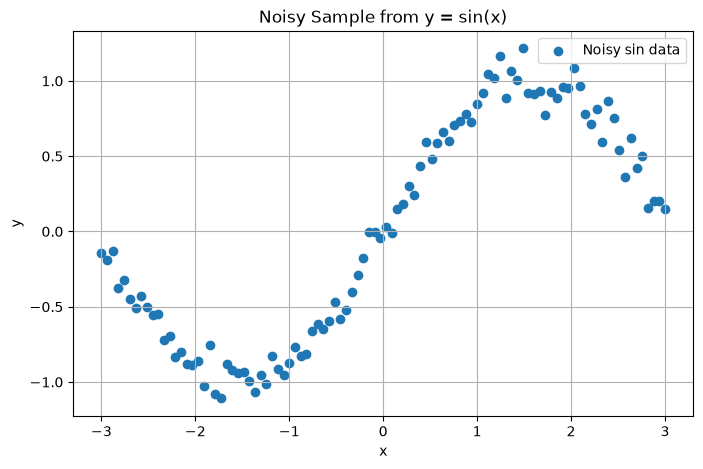

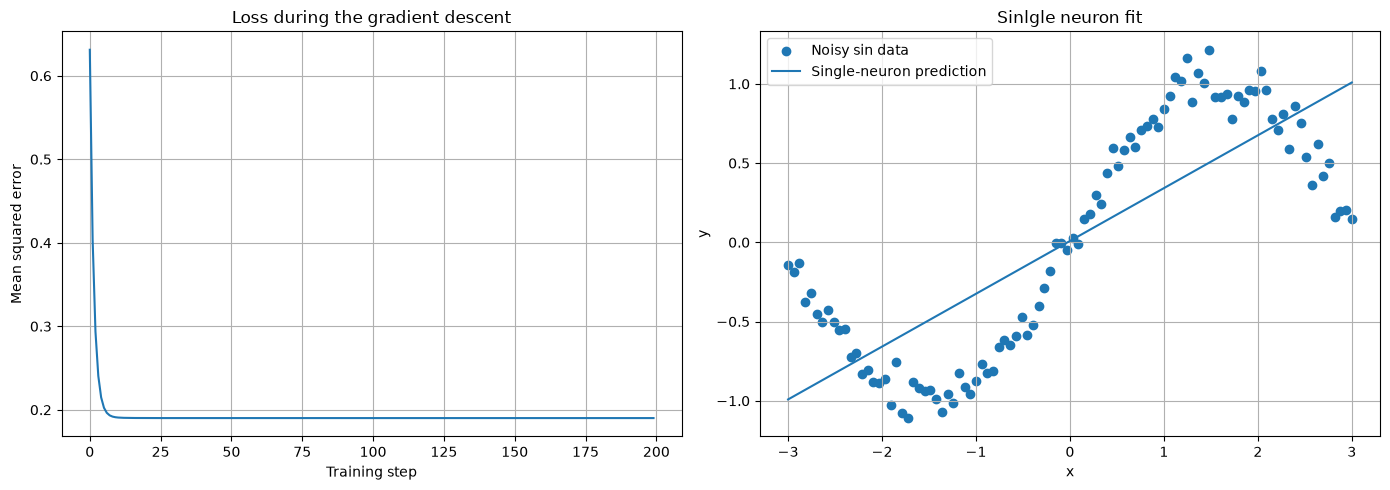

Final parameters:
Final weight: 0.333366
Final bias: 0.008574
Final loss: 0.190086


In [ ]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
x = np.linspace(-3, 3, 100)
noise = np.random.normal(loc=0, scale=0.1, size=100)
y = np.sin(x) + noise
#   Plot it.
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Noisy sin data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy Sample from y = sin(x)")
plt.legend()
plt.grid()
plt.show()
# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.05  # The learning rate set to a small value
steps = 200
losses = []

for step in range(steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)  # MSE
    dw = np.mean(2 * (y_hat - y) * x)  # dLoss/dw  (derive this on paper!)
    db = np.mean(2 * (y_hat - y))  # dLoss/db

    # Updating the parameters
    w -= lr * dw
    b -= lr * db
    # Record the loss at every step.
    losses.append(loss)

final_prediction = x * w + b

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot (a) the loss curve over the 200 step
axes[0].plot(losses)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Mean squared error")
axes[0].set_title("Loss during the gradient descent")
axes[0].grid()

# Plot (b) the data with the fitted line on top
axes[1].scatter(x, y, label="Noisy sin data")
axes[1].plot(x, final_prediction, label="Single-neuron prediction")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Sinlgle neuron fit")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

# Final parameters
print("Final parameters:")
print(f"Final weight: {w:4f}")
print(f"Final bias: {b:4f}")
print(f"Final loss: {losses[-1]:4f}")


**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** [Double-click to edit]

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

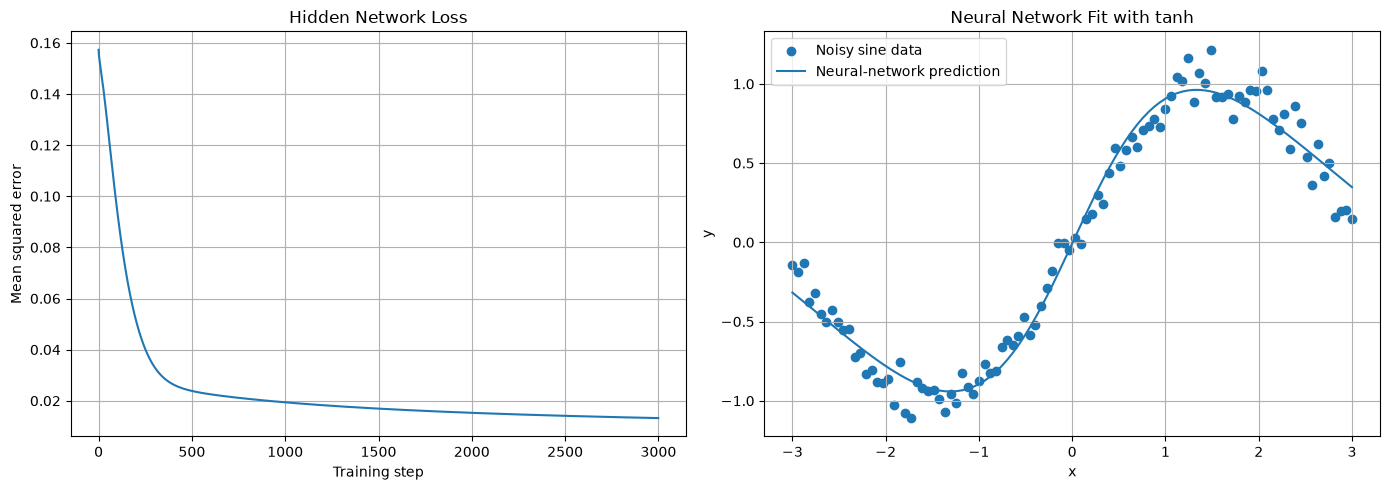

In [ ]:
np.random.seed(RANDOM_STATE)
# convertion of the shapes
X = x.reshape(-1, 1)
Y = y.reshape(-1, 1)
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
W1 = np.random.rand(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.rand(8, 1) * 0.5
b2 = np.zeros(1)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
lr = 0.05
steps = 3000
hidden_losses = []
for step in range(steps):
    # forward pass
    z1 = X @ W1 + b1  # pre-activation, shape (100, 8)
    h = np.tanh(z1)  # activation
    y_hat = h @ W2 + b2  # output, shape (100, 1)
    loss = np.mean((y_hat - Y) ** 2)
    hidden_losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - Y) / len(Y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)  # derivative of tanh
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0)

    # Updating the parameters
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

# Final prediction
z1 = X @ W1 + b1
h = np.tanh(z1)
final_predictions_hidden = h @ W2 + b2
# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
# Plot the loss and final fit.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve.
axes[0].plot(hidden_losses)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Mean squared error")
axes[0].set_title("Hidden Network Loss")
axes[0].grid()

# Final fit.
axes[1].scatter(X.flatten(), Y.flatten(), label="Noisy sine data")

axes[1].plot(
    X.flatten(), final_predictions_hidden.flatten(), label="Neural-network prediction"
)

axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Neural Network Fit with tanh")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

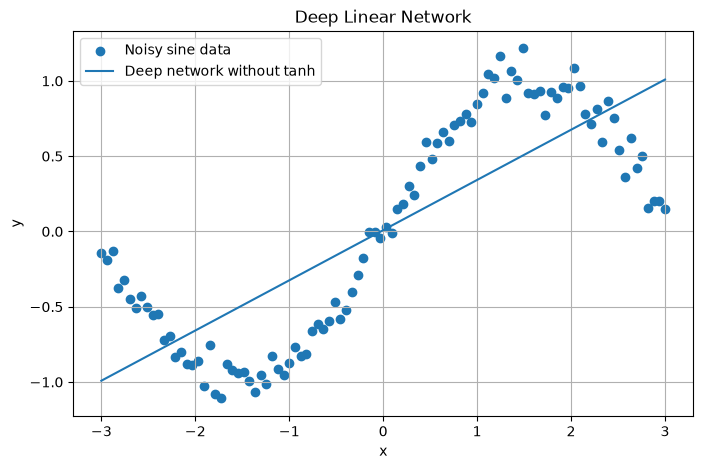

In [ ]:
# Compare the network without tanh.

np.random.seed(RANDOM_STATE)

W1_linear = np.random.randn(1, 8) * 0.5
b1_linear = np.zeros(8)

W2_linear = np.random.randn(8, 1) * 0.5
b2_linear = np.zeros(1)

linear_losses = []

for step in range(3000):
    # No activation:
    # h is simply z1.
    z1 = X @ W1_linear + b1_linear
    h = z1

    y_hat = h @ W2_linear + b2_linear

    loss = np.mean((y_hat - Y) ** 2)
    linear_losses.append(loss)

    d_yhat = 2 * (y_hat - Y) / len(Y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2_linear.T

    # The derivative of the identity function is 1.
    dz1 = dh

    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0)

    W1_linear -= 0.01 * dW1
    b1_linear -= 0.01 * db1

    W2_linear -= 0.01 * dW2
    b2_linear -= 0.01 * db2


# Final prediction without tanh.
h = X @ W1_linear + b1_linear
linear_predictions = h @ W2_linear + b2_linear

plt.figure(figsize=(8, 5))

plt.scatter(X.flatten(), Y.flatten(), label="Noisy sine data")

plt.plot(X.flatten(), linear_predictions.flatten(), label="Deep network without tanh")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Deep Linear Network")
plt.legend()
plt.grid()
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
1. Without tanh, every layer performs only a linear transformation. And the composition of linear transformations is still a linear function. 
2. Each hidden neuron learned a different nonlinear feature of the input after applying the tanh activation. Together, these neurons produced different basis functions that the output layer combined to approximate the sine wave. Instead of one straight line, the network learned several nonlinear components whose combination produced the final curve.
3. Backpropagation is the algorithm that uses the chain rule to compute the gradient of the loss with respect to every weight and bias in the network so they can be updated during training.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/Users/rydwandasilva/Ashesi year2-sem2/Intro to AI/ai_labs/lab_3/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/yn/3z6723893jj4d4k7g3hmyrkw0000gn/T/ipykernel_8329/1155312623.py:36: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - Y) ** 2)
/var/folders/yn/3z6723893jj4d4k7g3hmyrkw0000gn/T/ipykernel_8329/1155312623.py:47: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - h ** 2)
/Users/rydwandasilva/Ashesi year2-sem2/Intro to AI/ai_labs/lab_3/venv/lib/python3.13/site-packages/matplotlib/scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


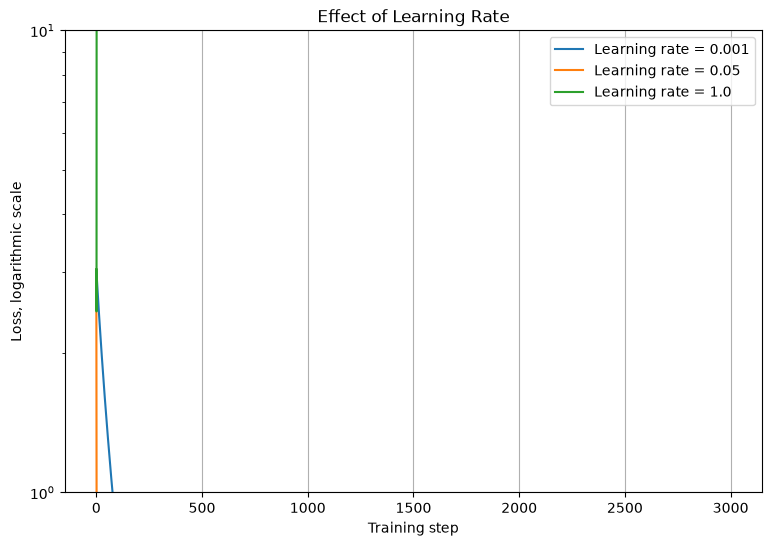

In [ ]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

# Part 1.3 — Compare learning rates


def train_toy(lr, steps=3000):

    # Reset the seed inside the function.
    # This gives every learning rate the same starting weights.
    np.random.seed(RANDOM_STATE)

    # Initialise the network.
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    # Store losses.
    losses = []

    # Training loop.
    for step in range(steps):
        # Forward pass.
        z1 = X @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        # Loss.
        loss = np.mean((y_hat - Y) ** 2)
        losses.append(loss)

        # Backward pass.
        d_yhat = 2 * (y_hat - Y) / len(Y)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T

        dz1 = dh * (1 - h**2)

        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0)

        # Parameter updates.
        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2

    return losses


# Train using three different learning rates.
losses_small_lr = train_toy(lr=0.001)
losses_good_lr = train_toy(lr=0.05)
losses_large_lr = train_toy(lr=1.0)


# Plot the loss curves.
plt.figure(figsize=(9, 6))

plt.plot(losses_small_lr, label="Learning rate = 0.001")

plt.plot(losses_good_lr, label="Learning rate = 0.05")

plt.plot(losses_large_lr, label="Learning rate = 1.0")

plt.yscale("log")

plt.xlabel("Training step")
plt.ylabel("Loss, logarithmic scale")
plt.title("Effect of Learning Rate")
plt.legend()
plt.grid()

plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** The small learning rate decreased the loss steadily but slowly because the parameter updates were very small. The medium learning rate converged much faster while remaining stable, making it the best choice. The large learning rate caused the loss to oscillate or even explode because each update overshot the minimum of the loss function, preventing the optimizer from converging.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
df = pd.read_csv(OBESITY_URL)
x_df = df.drop(columns="NObeyesdad").copy()
y_df = df["NObeyesdad"]

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_df)
class_names = label_encoder.classes_

binary_columns = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_columns:
    x_df[col] = x_df[col].map({"yes": 1, "no": 0})

# Ordinal
order_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
x_df["CAEC"] = x_df["CAEC"].map(order_map)
x_df["CALC"] = x_df["CALC"].map(order_map)

# Nominal → one-hot
x_df = pd.get_dummies(x_df, columns=["Gender", "MTRANS"], drop_first=True)

X = x_df.values.astype("float32")


# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=RANDOM_STATE, stratify=y_tv
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
def make_loader(X_arr, y_arr, batch_size=32, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X_arr, dtype=torch.float32), torch.tensor(y_arr, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


train_loader = make_loader(X_train, y_train, batch_size=32, shuffle=True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_test, y_test)

input_dim = X_train.shape[1]
print(
    f"Input dim: {input_dim}  |  Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}"
)


Input dim: 19  |  Train: 1266  Val: 422  Test: 423


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 
1. CrossEntropyLoss expects each training example to belong to exactly one class. Instead of receiving one-hot vectors, it receives the integer index of the correct class (for example, 3). It internally applies LogSoftmax and compares the predicted logits with the target class index, making integer labels both more efficient and the expected input format.
2. Neural networks use gradient descent, and the gradients depend on the magnitude of the input features. If some features have much larger values than others, their gradients become much larger, causing unstable or slow training. Scaling the features keeps gradients at similar magnitudes, allowing the optimizer to converge more efficiently. Decision trees and random forests split on feature values rather than using gradients, so they are much less sensitive to scaling.
3. shuffle=True randomly changes the order of the training examples every epoch. This prevents the model from learning patterns based on the order of the data and produces more representative mini-batches, leading to more stable gradient estimates and better generalization.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [ ]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)


class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, n_classes))  # raw logits — no softmax
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# TODO: Instantiate, move to DEVICE, print the model.
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(
    DEVICE
)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params}")
print(f"First layer check (input_dim * 64 + 64 = {input_dim * 64 + 64})")

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)

Trainable parameters: 3591
First layer check (input_dim * 64 + 64 = 1280)


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** 
2. ReLU is computationally simpler and helps reduce the vanishing gradient problem because its gradient is 1 for positive inputs. This allows gradients to flow more effectively through deep networks, leading to faster and more stable training than tanh
3. Removing the ReLU activations would make every layer linear. As shown in Section 1.2, multiple linear layers collapse into a single linear transformation, greatly reducing the network's ability to learn complex nonlinear patterns.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch   1 | tr_loss 1.7978 tr_acc 0.3294 | va_loss 1.8039 va_acc 0.3175
Epoch  10 | tr_loss 0.4033 tr_acc 0.8799 | va_loss 0.4792 va_acc 0.8318
Epoch  20 | tr_loss 0.1592 tr_acc 0.9652 | va_loss 0.2782 va_acc 0.8981
Epoch  30 | tr_loss 0.0774 tr_acc 0.9874 | va_loss 0.2356 va_acc 0.9218
Epoch  40 | tr_loss 0.0397 tr_acc 0.9976 | va_loss 0.2132 va_acc 0.9289
Epoch  50 | tr_loss 0.0219 tr_acc 1.0000 | va_loss 0.2123 va_acc 0.9313


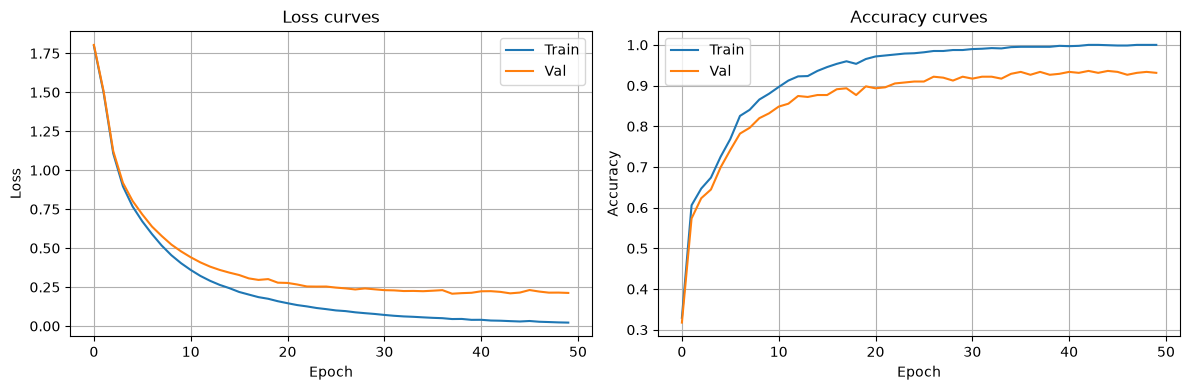

In [ ]:
import copy


def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_weights = None

    for epoch in range(1, epochs + 1):
        #  Train
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()  # clear gradients from last step
            logits = model(xb)  # forward pass
            loss = criterion(logits, yb)  # loss
            loss.backward()  # backprop (automates Part 1.2)
            optimizer.step()  # gradient descent step (automates Part 1.1)

        #  Evaluate
        model.eval()
        with torch.no_grad():

            def eval_split(loader):
                total_loss, correct, n = 0.0, 0, 0
                for xb, yb in loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    logits = model(xb)
                    total_loss += criterion(logits, yb).item() * len(yb)
                    correct += (logits.argmax(1) == yb).sum().item()
                    n += len(yb)
                return total_loss / n, correct / n

            tr_loss, tr_acc = eval_split(train_loader)
            va_loss, va_acc = eval_split(val_loader)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_weights = copy.deepcopy(model.state_dict())

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:3d} | tr_loss {tr_loss:.4f} tr_acc {tr_acc:.4f} "
                f"| va_loss {va_loss:.4f} va_acc {va_acc:.4f}"
            )

    # Save best weights
    torch.save(best_weights, "ffn_best.pt")
    model.load_state_dict(best_weights)  # restore best for evaluation
    return history


model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(
    DEVICE
)
history = train_model(model, train_loader, val_loader, epochs=50, lr=1e-3)

#  Plot learning curves
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss curves")
ax1.legend()
ax1.grid()

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"], label="Val")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy curves")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** 
Forward pass: outputs = model(inputs)
Loss computation: loss = criterion(outputs, labels)
Gradient computation: loss.backward()
Parameter update: optimizer.step()
Gradient reset: optimizer.zero_grad()

The model is well-fitted because the training and validation accuracies are close. 
PyTorch accumulates gradients by default. If optimizer.zero_grad() is omitted, the gradients from previous batches are added to the new gradients, causing incorrect parameter updates and preventing proper learning.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

Experiment A (Capacity)
Epoch   1 | tr_loss 1.8724 tr_acc 0.2125 | va_loss 1.8742 va_acc 0.2204
Epoch  10 | tr_loss 1.2048 tr_acc 0.5340 | va_loss 1.2258 va_acc 0.5261
Epoch  20 | tr_loss 0.8797 tr_acc 0.6912 | va_loss 0.9228 va_acc 0.6493
Epoch  30 | tr_loss 0.7137 tr_acc 0.7472 | va_loss 0.7704 va_acc 0.7180
Epoch  40 | tr_loss 0.6045 tr_acc 0.7930 | va_loss 0.6667 va_acc 0.7867
Epoch  50 | tr_loss 0.5226 tr_acc 0.8365 | va_loss 0.5906 va_acc 0.8175
Epoch   1 | tr_loss 1.7710 tr_acc 0.4945 | va_loss 1.7775 va_acc 0.5047
Epoch  10 | tr_loss 0.4299 tr_acc 0.8744 | va_loss 0.4891 va_acc 0.8389
Epoch  20 | tr_loss 0.1589 tr_acc 0.9700 | va_loss 0.2703 va_acc 0.9028
Epoch  30 | tr_loss 0.0792 tr_acc 0.9897 | va_loss 0.2262 va_acc 0.9265
Epoch  40 | tr_loss 0.0415 tr_acc 0.9961 | va_loss 0.2298 va_acc 0.9336
Epoch  50 | tr_loss 0.0231 tr_acc 0.9992 | va_loss 0.2462 va_acc 0.9265
Epoch   1 | tr_loss 1.0342 tr_acc 0.5458 | va_loss 1.0591 va_acc 0.5545
Epoch  10 | tr_loss 0.0521 tr_acc 0.9905

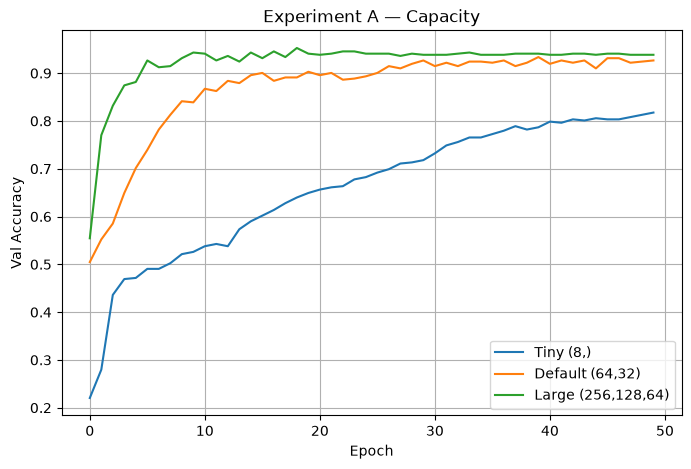

Experiment B (Learning rate)
Epoch   1 | tr_loss 1.9402 tr_acc 0.1714 | va_loss 1.9417 va_acc 0.1635
Epoch  10 | tr_loss 1.6490 tr_acc 0.4818 | va_loss 1.6631 va_acc 0.5071
Epoch  20 | tr_loss 1.2163 tr_acc 0.5900 | va_loss 1.2397 va_acc 0.5900
Epoch  30 | tr_loss 0.9707 tr_acc 0.6801 | va_loss 1.0058 va_acc 0.6517
Epoch  40 | tr_loss 0.8148 tr_acc 0.7338 | va_loss 0.8596 va_acc 0.7038
Epoch  50 | tr_loss 0.6987 tr_acc 0.7836 | va_loss 0.7522 va_acc 0.7393
Epoch   1 | tr_loss 1.7727 tr_acc 0.4621 | va_loss 1.7909 va_acc 0.4455
Epoch  10 | tr_loss 0.3865 tr_acc 0.8886 | va_loss 0.4680 va_acc 0.8412
Epoch  20 | tr_loss 0.1504 tr_acc 0.9684 | va_loss 0.2645 va_acc 0.9005
Epoch  30 | tr_loss 0.0709 tr_acc 0.9921 | va_loss 0.2182 va_acc 0.9313
Epoch  40 | tr_loss 0.0368 tr_acc 0.9961 | va_loss 0.2038 va_acc 0.9336
Epoch  50 | tr_loss 0.0191 tr_acc 1.0000 | va_loss 0.2058 va_acc 0.9408
Epoch   1 | tr_loss 1.1171 tr_acc 0.6027 | va_loss 1.2457 va_acc 0.6043
Epoch  10 | tr_loss 0.6932 tr_acc 0

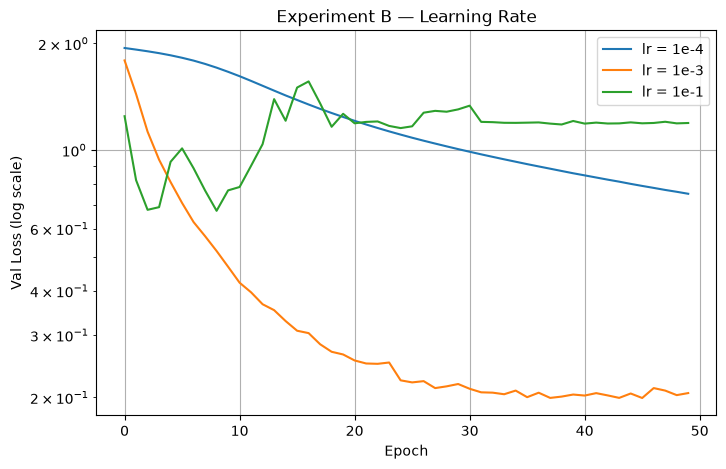

Experiment C (Dropout)
Epoch   1 | tr_loss 1.0292 tr_acc 0.6343 | va_loss 1.0517 va_acc 0.6469
Epoch  10 | tr_loss 0.0539 tr_acc 0.9905 | va_loss 0.2245 va_acc 0.9360
Epoch  20 | tr_loss 0.0094 tr_acc 0.9992 | va_loss 0.3153 va_acc 0.9218
Epoch  30 | tr_loss 0.0022 tr_acc 1.0000 | va_loss 0.3392 va_acc 0.9313
Epoch  40 | tr_loss 0.0010 tr_acc 1.0000 | va_loss 0.3824 va_acc 0.9313
Epoch  50 | tr_loss 0.0006 tr_acc 1.0000 | va_loss 0.4107 va_acc 0.9289
Epoch   1 | tr_loss 1.3535 tr_acc 0.5395 | va_loss 1.3611 va_acc 0.5545
Epoch  10 | tr_loss 0.1900 tr_acc 0.9439 | va_loss 0.2766 va_acc 0.9147
Epoch  20 | tr_loss 0.0912 tr_acc 0.9724 | va_loss 0.2644 va_acc 0.9052
Epoch  30 | tr_loss 0.0382 tr_acc 0.9929 | va_loss 0.2300 va_acc 0.9218
Epoch  40 | tr_loss 0.0235 tr_acc 0.9945 | va_loss 0.2219 va_acc 0.9384
Epoch  50 | tr_loss 0.0260 tr_acc 0.9913 | va_loss 0.2740 va_acc 0.9194


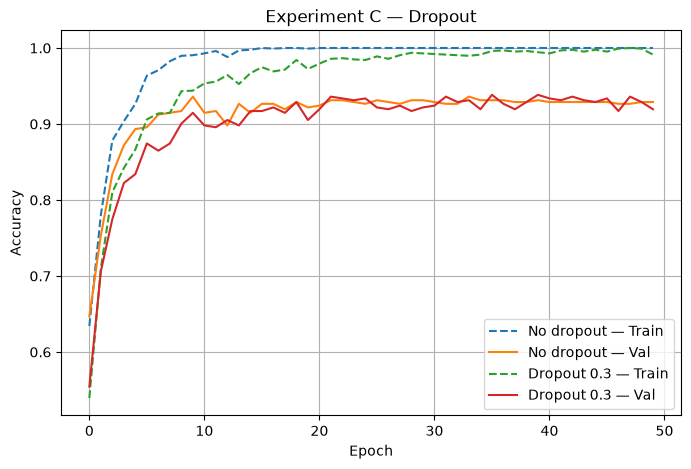

In [ ]:
# Wrap your Part 2.3 loop in a function first:
def run_experiment(
    hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0
):
    tr_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    m = FeedForwardNet(
        input_dim=input_dim, hidden_sizes=hidden_sizes, n_classes=7, dropout=dropout
    ).to(DEVICE)
    h = train_model(m, tr_loader, val_loader, epochs=epochs, lr=lr)
    return h, m


# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
print("Experiment A (Capacity)")
h_tiny, _ = run_experiment(hidden_sizes=(8,), epochs=50)
h_def, _ = run_experiment(hidden_sizes=(64, 32), epochs=50)
h_large, _ = run_experiment(hidden_sizes=(256, 128, 64), epochs=50)

plt.figure(figsize=(8, 5))
plt.plot(h_tiny["val_acc"], label="Tiny (8,)")
plt.plot(h_def["val_acc"], label="Default (64,32)")
plt.plot(h_large["val_acc"], label="Large (256,128,64)")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.title("Experiment A — Capacity")
plt.legend()
plt.grid()
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
print("Experiment B (Learning rate)")
h_slow, _ = run_experiment(lr=1e-4, epochs=50)
h_good, _ = run_experiment(lr=1e-3, epochs=50)
h_fast, _ = run_experiment(lr=1e-1, epochs=50)

plt.figure(figsize=(8, 5))
plt.plot(h_slow["val_loss"], label="lr = 1e-4")
plt.plot(h_good["val_loss"], label="lr = 1e-3")
plt.plot(h_fast["val_loss"], label="lr = 1e-1")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Val Loss (log scale)")
plt.title("Experiment B — Learning Rate")
plt.legend()
plt.grid()
plt.show()


# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
print("Experiment C (Dropout)")
h_no_drop, _ = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0, epochs=50)
h_drop, _ = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3, epochs=50)

plt.figure(figsize=(8, 5))
plt.plot(h_no_drop["train_acc"], label="No dropout — Train", linestyle="--")
plt.plot(h_no_drop["val_acc"], label="No dropout — Val")
plt.plot(h_drop["train_acc"], label="Dropout 0.3 — Train", linestyle="--")
plt.plot(h_drop["val_acc"], label="Dropout 0.3 — Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment C — Dropout")
plt.legend()
plt.grid()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [19]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# TODO: Load your best configuration's weights; model.eval().
model.load_state_dict(torch.load("ffn_best.pt", map_location=DEVICE))
model.eval()

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

test_acc = accuracy_score(all_true, all_preds)
test_f1 = f1_score(all_true, all_preds, average="macro")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Macro-F1 : {test_f1:.4f}")
print()
print(classification_report(all_true, all_preds, target_names=class_names))

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    all_true, all_preds, display_labels=class_names, xticks_rotation=45, ax=ax
)
ax.set_title("Confusion Matrix — Neural Network (Test Set)")
plt.tight_layout()
plt.show()

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
comparison = pd.DataFrame(
    {
        "Model": ["Random Forest (Lab 2)", "Neural Network (Lab 3)"],
        "Test Accuracy": ["0.9953", f"{test_acc:.4f}"],
        "Test Macro-F1": ["0.9955", f"{test_f1:.4f}"],
        "Notes": ["sklearn RF, 100 trees", "MLP 64→32, Adam lr=1e-3, 50 epochs"],
    }
)
print(comparison.to_string(index=False))

RuntimeError: Error(s) in loading state_dict for FeedForwardNet:
	Missing key(s) in state_dict: "net.2.weight", "net.2.bias", "net.4.weight", "net.4.bias". 
	Unexpected key(s) in state_dict: "net.6.weight", "net.6.bias", "net.9.weight", "net.9.bias", "net.3.weight", "net.3.bias". 
	size mismatch for net.0.weight: copying a param with shape torch.Size([256, 19]) from checkpoint, the shape in current model is torch.Size([64, 19]).
	size mismatch for net.0.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([64]).

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** 
1. 
- The loss.backward() performs backpropagation, it uses the chain rule to calculate how much each weight and bias contributed to the loss
- The optimizer.step() uses the computed gradients to adjust the model's weights and biases in the direction that reduces loss.
2. 
I would tune the learning rate first because it has the greatest impact on whether the model trains successfully. If the learning rate is too small, the training becomes very slow. If it is too large, the optimizer may overshoot the minimum loss and fail to converge. A good learning rate allows the model to learn efficiently, making it easier to evaluate the effects of other hyperparameters later. 
3.

4.
A plain MLP treats every input feature as independent and does not take into account the spatial relationships between neighbouring pixels. As a result, it cannot efficiently recognise local patterns such as edges, corners, or textures and requires a very large number of parameters for images. A better architecture should exploit the spatial structure of images by learning local features and reusing the same filters across different regions. This is the idea behind Convolutional Neural Networks (CNNs), which are more efficient for image recognition tasks.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.